In [ ]:
import mne
import numpy as np
import pandas as pd
import os
from scipy.signal import hilbert
import warnings

# --- 1. 用户参数设置 ---
subjects = [1, 2, 6, 7, 10, 11, 16, 20, 21, 25]
in_roi1_path = '/root/seeg_roi_1246/vmpfc/'
in_roi2_path = '/root/seeg_roi_1246/acc/'
output_path = '/root/results/trial_level_connectivity/'
os.makedirs(output_path, exist_ok=True)

# 分析参数
fmin, fmax = 4, 9  # Theta 频段 (4-8 Hz)
# 决策时间窗口：建议你的原始数据比这个范围左右各多出至少 500ms
#decision_tmin, decision_tmax = -1.2, 0.1  
decision_tmin, decision_tmax = -1.1, 0.15  
# --- 2. 主循环：遍历所有被试 ---
all_results_list = []

print(f"开始计算 PLV... 频段: {fmin}-{fmax} Hz, 窗口: {decision_tmin}s ~ {decision_tmax}s")

for subj in subjects:
    subject_code = str(subj)
    print(f"\n--- 正在处理被试: {subject_code} ---")
    
    try:
        # A. 导入数据 (读取完整的 Epoch)
        epochs1 = mne.read_epochs_eeglab(os.path.join(in_roi1_path, f"{subject_code}.set"), verbose=False)
        epochs2 = mne.read_epochs_eeglab(os.path.join(in_roi2_path, f"{subject_code}.set"), verbose=False)

        # 排除特定事件 (Tag 99)
        selected_tags = [tag for tag in epochs1.event_id if '99' not in tag]
        epochs1 = epochs1[selected_tags]
        epochs2 = epochs2[selected_tags]

        if len(epochs1) != len(epochs2):
            warnings.warn(f"被试 {subject_code} Epoch数量不匹配，跳过。")
            continue

        # B. 核心改进：【先滤波，后裁剪】
        # 目的是让滤波器的起始震荡（Edge Artifacts）发生在裁剪掉的区域
        
        epochs1.filter(fmin, fmax, fir_design='firwin', verbose=False)
        epochs2.filter(fmin, fmax, fir_design='firwin', verbose=False)

        # 裁剪到目标分析窗口
        epochs1.crop(tmin=decision_tmin, tmax=decision_tmax)
        epochs2.crop(tmin=decision_tmin, tmax=decision_tmax)

        # 获取数据矩阵 (n_epochs, n_channels, n_times)
        data1 = epochs1.get_data(copy=False)
        data2 = epochs2.get_data(copy=False)
        ch_names1 = epochs1.ch_names
        ch_names2 = epochs2.ch_names
        n_epochs, n_ch1, n_times = data1.shape
        n_ch2 = data2.shape[1]

        # C. 核心计算：计算瞬时相位 (Hilbert 变换)
        # axis=-1 表示在时间轴上计算
        phase1 = np.angle(hilbert(data1, axis=-1))
        phase2 = np.angle(hilbert(data2, axis=-1))

        # D. 向量化 PLV 计算
        # PLV 公式: |1/T * sum(exp(i * (phase1 - phase2)))|
        
        print(f"  正在计算 {n_epochs} 个试验的通道间 PLV 矩阵...")
        
        for e in range(n_epochs):
            # 提取当前 Trial 的相位 (n_ch, n_times)
            p1 = phase1[e, :, :]
            p2 = phase2[e, :, :]

            # 【广播机制优化】：一次性计算所有通道两两之间的相位差
            # (n_ch1, 1, n_times) - (1, n_ch2, n_times) -> (n_ch1, n_ch2, n_times)
            phase_diff = p1[:, np.newaxis, :] - p2[np.newaxis, :, :]

            # 在时间维度上求平均并取绝对值
            # 这里的 plv_matrix 形状为 (n_ch1, n_ch2)
            plv_matrix = np.abs(np.mean(np.exp(1j * phase_diff), axis=2))

            # 快速将矩阵结果转换为列表存储
            # 这种方法比原先的三重循环快得多
            for i in range(n_ch1):
                for j in range(n_ch2):
                    all_results_list.append({
                        'subject': subject_code,
                        'trial_index': e,
                        'roi1_channel': ch_names1[i],
                        'roi2_channel': ch_names2[j],
                        'plv': plv_matrix[i, j]
                    })

            if (e + 1) % 50 == 0:
                print(f"    进度: {e + 1}/{n_epochs} trials 已完成")

    except Exception as e:
        print(f"  !! 处理被试 {subject_code} 时出错: {e}")

# --- 3. 结果保存 ---
if all_results_list:
    print("\n--- 正在生成最终 CSV 文件... ---")
    results_df = pd.DataFrame(all_results_list)
    output_file = os.path.join(output_path, f"trial_level_plv_{fmin}-{fmax}Hz.csv")
    results_df.to_csv(output_file, index=False)
    print(f"成功！结果已保存至: {output_file}")
    print(results_df.head())
else:
    print("没有生成任何有效数据。")

开始计算 PLV... 频段: 4-9 Hz, 窗口: -1.1s ~ 0.15s

--- 正在处理被试: 1 ---


/tmp/ipykernel_1025/1973488382.py:31: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  epochs1 = mne.read_epochs_eeglab(os.path.join(in_roi1_path, f"{subject_code}.set"), verbose=False)
/tmp/ipykernel_1025/1973488382.py:32: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  epochs2 = mne.read_epochs_eeglab(os.path.join(in_roi2_path, f"{subject_code}.set"), verbose=False)


  正在计算 50 个试验的通道间 PLV 矩阵...
    进度: 50/50 trials 已完成

--- 正在处理被试: 2 ---


/tmp/ipykernel_1025/1973488382.py:31: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  epochs1 = mne.read_epochs_eeglab(os.path.join(in_roi1_path, f"{subject_code}.set"), verbose=False)
/tmp/ipykernel_1025/1973488382.py:32: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  epochs2 = mne.read_epochs_eeglab(os.path.join(in_roi2_path, f"{subject_code}.set"), verbose=False)


  正在计算 77 个试验的通道间 PLV 矩阵...
    进度: 50/77 trials 已完成

--- 正在处理被试: 6 ---


...

  正在计算 98 个试验的通道间 PLV 矩阵...
    进度: 50/98 trials 已完成

--- 正在处理被试: 21 ---


/tmp/ipykernel_1025/1973488382.py:31: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  epochs1 = mne.read_epochs_eeglab(os.path.join(in_roi1_path, f"{subject_code}.set"), verbose=False)
/tmp/ipykernel_1025/1973488382.py:32: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  epochs2 = mne.read_epochs_eeglab(os.path.join(in_roi2_path, f"{subject_code}.set"), verbose=False)


  正在计算 96 个试验的通道间 PLV 矩阵...
    进度: 50/96 trials 已完成

--- 正在处理被试: 25 ---


/tmp/ipykernel_1025/1973488382.py:31: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  epochs1 = mne.read_epochs_eeglab(os.path.join(in_roi1_path, f"{subject_code}.set"), verbose=False)
/tmp/ipykernel_1025/1973488382.py:32: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  epochs2 = mne.read_epochs_eeglab(os.path.join(in_roi2_path, f"{subject_code}.set"), verbose=False)


  正在计算 75 个试验的通道间 PLV 矩阵...
    进度: 50/75 trials 已完成

--- 正在生成最终 CSV 文件... ---
成功！结果已保存至: /root/results/trial_level_connectivity/trial_level_plv_4-9Hz.csv
  subject  trial_index roi1_channel roi2_channel       plv
0       1            0    OB'1_OB'3    MF'5_MF'7  0.302805
1       1            0    OB'1_OB'3    MF'7_MF'9  0.428457
2       1            0    OB'1_OB'3   MF'9_MF'11  0.587275
3       1            0    OB'1_OB'3      MF7_MF9  0.217299
4       1            0    OB'1_OB'3     MF9_MF11  0.504149


In [ ]:
#!/usr/bin/env python3
import pandas as pd
import numpy as np
import os
import statsmodels.api as sm
from scipy.stats import ttest_1samp
import warnings
import mne

# --- 1. 参数和路径设置 ---
subjects = [1, 2, 6, 7, 10, 11, 16, 20, 21, 25] 
connectivity_data_path = '/root/results/trial_level_connectivity/'
seeg_epochs_path = '/root/seeg_roi_1246/vmpfc/'
model_data_path = '/root/results/bhm_final_fix_beta_26/weighted/'
output_path = '/root/results/plv_behavior_regression/weighted/'
os.makedirs(output_path, exist_ok=True)

fmin, fmax = 4, 8
plv_filepath = os.path.join(connectivity_data_path, f"trial_level_plv_{fmin}-{fmax}Hz.csv")

# --- 2. 加载并整合数据 (保持原有逻辑) ---
try:
    plv_df = pd.read_csv(plv_filepath)
    plv_df['subject'] = plv_df['subject'].astype(str)
except FileNotFoundError:
    print(f"错误: 找不到PLV文件 at {plv_filepath}"); exit(1)

all_subjects_behavior_df_list = []
for subject_id in subjects:
    try:
        # 加载行为模型数据 (HBM)
        game_metrics_path = os.path.join(model_data_path, f"{subject_id}_game_metrics.csv")
        if not os.path.exists(game_metrics_path): continue
        
        this_game_metrics = pd.read_csv(game_metrics_path)
        this_rel_rewards, this_info_gains, this_valid_epochs = [], [], []

        # 行为变量提取
        for epoch_idx in range(len(this_game_metrics)):
            game = epoch_idx + 1
            game_data = this_game_metrics[this_game_metrics['Game'] == game]
            if game_data.empty: continue
            
            chosen_deck = int(game_data['Chosen_Deck'].iloc[0])
            # Reward: Q_chosen - mean(Q_unchosen)
            q_cols = [f'Q_Deck_{d}' for d in range(1, 4)]
            q_chosen = game_data[f'Q_Deck_{chosen_deck}'].iloc[0]
            rel_reward = q_chosen - game_data[q_cols].mean(axis=1).iloc[0]
            
            # Info Gain
            info_gain = game_data[f'Weighted_I_transformed_Deck_{chosen_deck}'].iloc[0]
            
            this_rel_rewards.append(rel_reward)
            this_info_gains.append(info_gain)
            this_valid_epochs.append(epoch_idx)

        all_subjects_behavior_df_list.append(pd.DataFrame({
            'subject': str(subject_id), 'trial_index': this_valid_epochs,
            'relative_reward': this_rel_rewards, 'information_gain': this_info_gains
        }))
    except Exception as e: print(f"处理被试 {subject_id} 出错: {e}")

behavior_df = pd.concat(all_subjects_behavior_df_list, ignore_index=True)
merged_df = pd.merge(plv_df, behavior_df, on=['subject', 'trial_index'], how='inner')

# --- 3. 修改核心回归逻辑：Behavior -> PLV ---

print("\n" + "=" * 70)
print("步骤2: 执行编码模型 (Behavior Predicts PLV)")
print("=" * 70)

channel_pairs = merged_df[['roi1_channel', 'roi2_channel']].drop_duplicates()
regression_results = []

for idx, (_, row) in enumerate(channel_pairs.iterrows()):
    ch1, ch2 = row['roi1_channel'], row['roi2_channel']
    pair_df = merged_df[(merged_df['roi1_channel'] == ch1) & (merged_df['roi2_channel'] == ch2)].copy()
    
    if len(pair_df) < 20: continue

    # 1. Z-score 标准化 (为了让 Beta 系数可比)
    pair_df['reward_z'] = (pair_df['relative_reward'] - pair_df['relative_reward'].mean()) / pair_df['relative_reward'].std()
    pair_df['info_z'] = (pair_df['information_gain'] - pair_df['information_gain'].mean()) / pair_df['information_gain'].std()
    pair_df['plv_z'] = (pair_df['plv'] - pair_df['plv'].mean()) / pair_df['plv'].std()

    # 2. 正交化处理 (处理 r > 0.7 的共线性)
    # 将 Info Gain 对 Reward 做线性回归，取残差作为“纯净的” Info Gain
    slope, intercept = np.polyfit(pair_df['reward_z'], pair_df['info_z'], 1)
    pair_df['info_orth'] = pair_df['info_z'] - (slope * pair_df['reward_z'] + intercept)

    # 3. 构建多重回归模型
    # DV: PLV, IVs: Reward_z, Info_orth
    X = sm.add_constant(pair_df[['reward_z', 'info_orth']])
    y = pair_df['plv_z']
    
    try:
        model = sm.OLS(y, X, missing='drop').fit()
        
        regression_results.append({
            'roi1_channel': ch1, 'roi2_channel': ch2, 'n_trials': len(pair_df),
            'beta_reward': model.params['reward_z'],
            'p_reward': model.pvalues['reward_z'],
            'beta_info': model.params['info_orth'],
            'p_info': model.pvalues['info_orth'],
            'r_squared': model.rsquared
        })
    except Exception as e:
        warnings.warn(f"回归失败 {ch1}-{ch2}: {e}")

results_df = pd.DataFrame(regression_results)
results_df.to_csv(os.path.join(output_path, "behavior_predict_plv_results.csv"), index=False)

# --- 4. 统计分析 (单样本 t 检验) ---
print("\n=== 整体效应分析 (Group-level T-test) ===")
for var in ['reward', 'info']:
    betas = results_df[f'beta_{var}']
    t_stat, p_val = ttest_1samp(betas, 0)
    print(f"{var.capitalize()} Effect:")
    print(f"  Mean Beta: {betas.mean():.4f}, t({len(betas)-1})={t_stat:.3f}, p={p_val:.4f}")

# 统计显著的通道对
sig_reward = (results_df['p_reward'] < 0.05).sum()
sig_info = (results_df['p_info'] < 0.05).sum()
print(f"\n显著通道对 (p < 0.05):")
print(f"  Reward: {sig_reward}/{len(results_df)}")
print(f"  Info: {sig_info}/{len(results_df)}")


步骤2: 执行编码模型 (Behavior Predicts PLV)

=== 整体效应分析 (Group-level T-test) ===
Reward Effect:
  Mean Beta: 0.0171, t(1719)=7.192, p=0.0000
Info Effect:
  Mean Beta: -0.0013, t(1719)=-0.295, p=0.7677

显著通道对 (p < 0.05):
  Reward: 84/1720
  Info: 104/1720


In [ ]:
#!/usr/bin/env python3
import pandas as pd
import numpy as np
import os
import statsmodels.api as sm
from scipy.stats import ttest_1samp
import warnings
from tqdm import tqdm
import matplotlib.pyplot as plt

# --- 1. 参数和路径设置 ---
subjects = [1, 2, 6, 7, 10, 11, 16, 20, 21, 25] 
connectivity_data_path = '/root/results/trial_level_connectivity/'
# seeg_epochs_path 这里用不到了，因为直接读 csv
model_data_path = '/root/results/bhm_final_fix_beta_26/weighted/'
output_path = '/root/results/plv_behavior_regression/permutation/'
os.makedirs(output_path, exist_ok=True)

fmin, fmax = 4, 8
plv_filepath = os.path.join(connectivity_data_path, f"trial_level_plv_{fmin}-{fmax}Hz.csv")
n_permutations = 5000  # 置换次数

# --- 2. 加载并整合数据 (保持原有逻辑) ---
print("=" * 70)
print("步骤1: 加载并合并数据")
print("=" * 70)
try:
    plv_df = pd.read_csv(plv_filepath)
    plv_df['subject'] = plv_df['subject'].astype(str)
except FileNotFoundError:
    print(f"错误: 找不到PLV文件 at {plv_filepath}"); exit(1)

all_subjects_behavior_df_list = []
for subject_id in subjects:
    try:
        game_metrics_path = os.path.join(model_data_path, f"{subject_id}_game_metrics.csv")
        if not os.path.exists(game_metrics_path): continue
        
        this_game_metrics = pd.read_csv(game_metrics_path)
        this_rel_rewards, this_info_gains, this_valid_epochs = [], [], []

        for epoch_idx in range(len(this_game_metrics)):
            game = epoch_idx + 1
            game_data = this_game_metrics[this_game_metrics['Game'] == game]
            if game_data.empty: continue
            
            chosen_deck = int(game_data['Chosen_Deck'].iloc[0])
            q_cols = [f'Q_Deck_{d}' for d in range(1, 4)]
            q_chosen = game_data[f'Q_Deck_{chosen_deck}'].iloc[0]
            rel_reward = q_chosen - game_data[q_cols].mean(axis=1).iloc[0]
            
            info_gain = game_data[f'Weighted_I_transformed_Deck_{chosen_deck}'].iloc[0]
            
            this_rel_rewards.append(rel_reward)
            this_info_gains.append(info_gain)
            this_valid_epochs.append(epoch_idx)

        all_subjects_behavior_df_list.append(pd.DataFrame({
            'subject': str(subject_id), 'trial_index': this_valid_epochs,
            'relative_reward': this_rel_rewards, 'information_gain': this_info_gains
        }))
    except Exception as e: print(f"处理被试 {subject_id} 出错: {e}")

behavior_df = pd.concat(all_subjects_behavior_df_list, ignore_index=True)
merged_df = pd.merge(plv_df, behavior_df, on=['subject', 'trial_index'], how='inner')

# --- 3. 提取特征矩阵与真实观测 Beta ---
print("\n" + "=" * 70)
print("步骤2: 提取特征矩阵，执行真实模型 (Observed GLM)")
print("=" * 70)

channel_pairs = merged_df[['roi1_channel', 'roi2_channel']].drop_duplicates()
regression_results = []

# 为了加速置换检验，我们把所有电极对的 X 矩阵和 y 向量提前存起来
X_list = []
y_list = []
pair_names = []

for idx, (_, row) in enumerate(channel_pairs.iterrows()):
    ch1, ch2 = row['roi1_channel'], row['roi2_channel']
    pair_df = merged_df[(merged_df['roi1_channel'] == ch1) & (merged_df['roi2_channel'] == ch2)].copy()
    
    if len(pair_df) < 20: continue

    # 1. Z-score 标准化
    pair_df['reward_z'] = (pair_df['relative_reward'] - pair_df['relative_reward'].mean()) / pair_df['relative_reward'].std()
    pair_df['info_z'] = (pair_df['information_gain'] - pair_df['information_gain'].mean()) / pair_df['information_gain'].std()
    pair_df['plv_z'] = (pair_df['plv'] - pair_df['plv'].mean()) / pair_df['plv'].std()

    # 2. 正交化处理
    slope, intercept = np.polyfit(pair_df['reward_z'], pair_df['info_z'], 1)
    pair_df['info_orth'] = pair_df['info_z'] - (slope * pair_df['reward_z'] + intercept)

    # 3. 构建多重回归模型
    X = sm.add_constant(pair_df[['reward_z', 'info_orth']])
    y = pair_df['plv_z']
    
    try:
        model = sm.OLS(y, X, missing='drop').fit()
        
        regression_results.append({
            'roi1_channel': ch1, 'roi2_channel': ch2, 'n_trials': len(pair_df),
            'beta_reward': model.params['reward_z'],
            'p_reward': model.pvalues['reward_z'],
            'beta_info': model.params['info_orth'],
            'p_info': model.pvalues['info_orth']
        })
        
        # 存入列表供置换检验快速调用 (转化为 numpy array 以提升百倍速度)
        X_list.append(X.values)
        y_list.append(y.values)
        pair_names.append(f"{ch1}-{ch2}")
        
    except Exception as e:
        pass

results_df = pd.DataFrame(regression_results)
results_df.to_csv(os.path.join(output_path, "observed_predict_plv_results.csv"), index=False)

# 真实的平均 Beta (Group-level)
obs_mean_beta_reward = results_df['beta_reward'].mean()
obs_mean_beta_info = results_df['beta_info'].mean()

print(f"观测效应 (Observed Mean Beta):")
print(f"  Reward: {obs_mean_beta_reward:.5f}")
print(f"  Info:   {obs_mean_beta_info:.5f}")

# --- 4. 运行置换检验 (Permutation Test) ---
print("\n" + "=" * 70)
print(f"步骤3: 执行 {n_permutations} 次置换检验 (使用矩阵运算极速加速)")
print("=" * 70)

null_dist_reward = np.zeros(n_permutations)
null_dist_info = np.zeros(n_permutations)

# 使用矩阵乘法快速求解 Beta: (X^T X)^(-1) X^T y
# 提前计算伪逆矩阵 (X^T X)^(-1) X^T，因为在置换过程中 X 是不变的！
X_pinv_list = [np.linalg.pinv(X) for X in X_list]

for i in tqdm(range(n_permutations), desc="Permutation Progress"):
    temp_beta_reward = []
    temp_beta_info = []
    
    # 对每一个电极对进行打乱
    for y_true, X_pinv in zip(y_list, X_pinv_list):
        # 仅打乱因变量 PLV (破坏因果联系)
        y_shuffled = np.random.permutation(y_true)
        
        # 极速计算 OLS Beta
        betas = X_pinv @ y_shuffled
        
        temp_beta_reward.append(betas[1]) # betas[0] 是常数项，betas[1] 是 reward_z
        temp_beta_info.append(betas[2])   # betas[2] 是 info_orth
        
    # 记录这一次置换的 group-level mean beta
    null_dist_reward[i] = np.mean(temp_beta_reward)
    null_dist_info[i] = np.mean(temp_beta_info)

# --- 5. 计算最终的 Non-parametric P 值 ---
print("\n" + "=" * 70)
print("步骤4: 置换检验统计结果")
print("=" * 70)

p_perm_reward = (np.sum(np.abs(null_dist_reward) >= np.abs(obs_mean_beta_reward)) + 1) / (n_permutations + 1)
p_perm_info = (np.sum(np.abs(null_dist_info) >= np.abs(obs_mean_beta_info)) + 1) / (n_permutations + 1)

print(f"【Reward 效应】")
print(f"  Observed Mean Beta: {obs_mean_beta_reward:.5f}")
print(f"  Permutation P-value: {p_perm_reward:.4f}  {'*** 显著' if p_perm_reward<0.05 else ''}")

print(f"\n【Information 效应】")
print(f"  Observed Mean Beta: {obs_mean_beta_info:.5f}")
print(f"  Permutation P-value: {p_perm_info:.4f}  {'*** 显著' if p_perm_info<0.05 else ''}")

# --- 6. 可视化零分布 ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Reward 分布图
axes[0].hist(null_dist_reward, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].axvline(obs_mean_beta_reward, color='red', linestyle='dashed', linewidth=2, label=f'Observed: {obs_mean_beta_reward:.4f}')
axes[0].set_title(f'Null Distribution (Reward)\nPermutation p-value = {p_perm_reward:.4f}')
axes[0].set_xlabel('Group Mean Beta')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Info 分布图
axes[1].hist(null_dist_info, bins=50, color='lightcoral', edgecolor='black', alpha=0.7)
axes[1].axvline(obs_mean_beta_info, color='red', linestyle='dashed', linewidth=2, label=f'Observed: {obs_mean_beta_info:.4f}')
axes[1].set_title(f'Null Distribution (Info)\nPermutation p-value = {p_perm_info:.4f}')
axes[1].set_xlabel('Group Mean Beta')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(output_path, 'permutation_null_distribution.png'), dpi=300)
print(f"\n绘图已保存至: {os.path.join(output_path, 'permutation_null_distribution.png')}")


步骤1: 加载并合并数据

步骤2: 提取特征矩阵，执行真实模型 (Observed GLM)
观测效应 (Observed Mean Beta):
  Reward: 0.01712
  Info:   -0.00129

步骤3: 执行 5000 次置换检验 (使用矩阵运算极速加速)


Permutation Progress:  80%|███████▉  | 3976/5000 [01:12<00:18, 56.05it/s]

加载置换检验结果并生成增强版可视化

--- 加载数据 ---
✓ 观测数据加载成功: 1720 个通道对
✓ 零分布数据加载成功: 5000 次置换

--- 统计摘要 ---
Reward:
  观测平均Beta: 0.0171
  P-value: 0.0002
Information:
  观测平均Beta: -0.0013
  P-value: 0.7684

--- 生成增强版可视化 ---
✓ 增强版置换分布图已保存

--- 生成小提琴图 ---
✓ 小提琴图已保存

--- 生成条形图汇总 ---
✓ 条形图已保存

所有可视化完成！图片已保存至:
  /root/results/plv_behavior_regression/permutation/


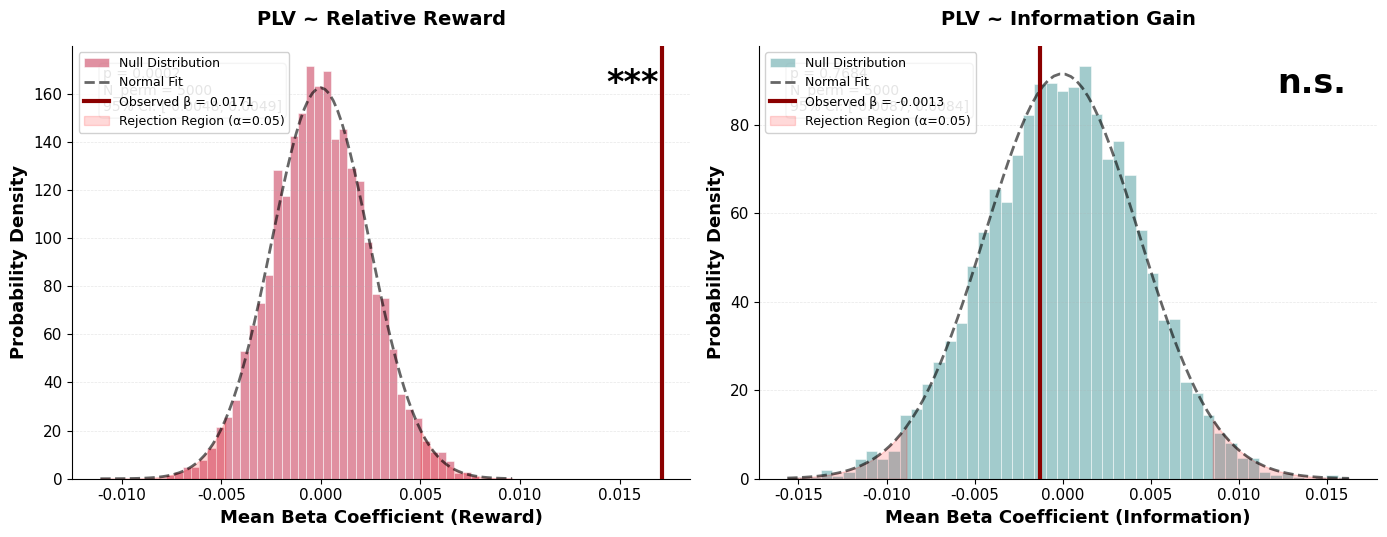

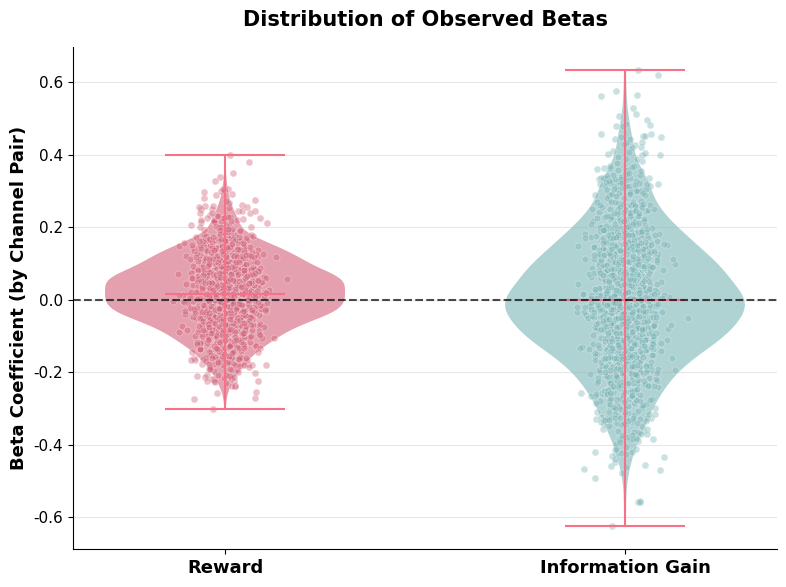

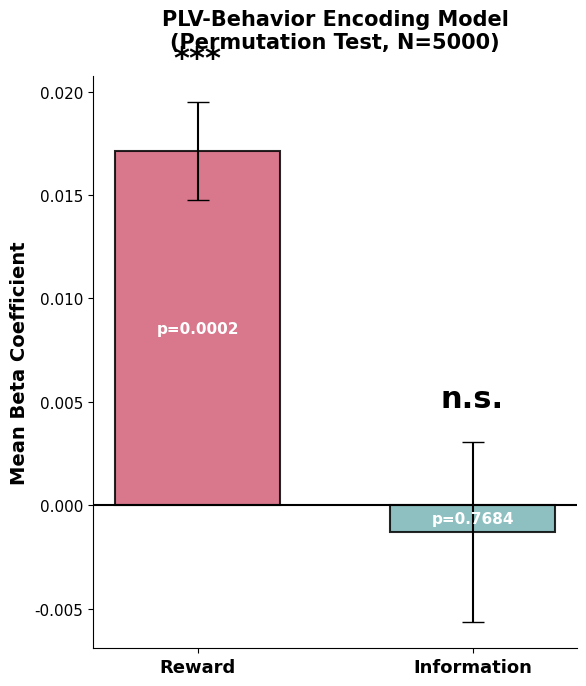

In [2]:
#!/usr/bin/env python3
"""
置换检验结果 - 增强版可视化 (适配高速矩阵 GLM 输出)
"""

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy import stats
import os
import warnings

# 禁用字体警告
warnings.filterwarnings('ignore', message='.*Font family.*not found.*')

# ================================================================
# 1. 设置路径和加载数据
# ================================================================
print("="*70)
print("加载置换检验结果并生成增强版可视化")
print("="*70)

# 注意这里对齐了你高速矩阵脚本的输出路径
output_path = '/root/results/plv_behavior_regression/permutation/'

print("\n--- 加载数据 ---")
try:
    # 读取高速脚本输出的文件名
    observed_df = pd.read_csv(os.path.join(output_path, 'observed_predict_plv_results.csv'))
    null_df = pd.read_csv(os.path.join(output_path, 'null_distributions.csv'))
    
    print(f"✓ 观测数据加载成功: {len(observed_df)} 个通道对")
    print(f"✓ 零分布数据加载成功: {len(null_df)} 次置换")
except Exception as e:
    print(f"✗ 数据加载失败: {e}\n请确保高速置换代码中已将 null_distributions 保存为 CSV！")
    exit(1)

# 提取数据
observed_betas_reward = observed_df['beta_reward'].dropna().values
observed_betas_info = observed_df['beta_info'].dropna().values
null_distribution_reward = null_df['null_beta_reward'].dropna().values
null_distribution_info = null_df['null_beta_info'].dropna().values

# 计算统计量
observed_mean_beta_reward = np.mean(observed_betas_reward)
observed_mean_beta_info = np.mean(observed_betas_info)

# 计算p值（双边检验）
p_value_perm_reward = (
    np.sum(np.abs(null_distribution_reward) >= np.abs(observed_mean_beta_reward)) + 1
) / (len(null_distribution_reward) + 1)

p_value_perm_info = (
    np.sum(np.abs(null_distribution_info) >= np.abs(observed_mean_beta_info)) + 1
) / (len(null_distribution_info) + 1)

print(f"\n--- 统计摘要 ---")
print(f"Reward:")
print(f"  观测平均Beta: {observed_mean_beta_reward:.4f}")
print(f"  P-value: {p_value_perm_reward:.4f}")
print(f"Information:")
print(f"  观测平均Beta: {observed_mean_beta_info:.4f}")
print(f"  P-value: {p_value_perm_info:.4f}")

# ================================================================
# 2. 增强版可视化设定
# ================================================================
print("\n--- 生成增强版可视化 ---")

# 使用系统通用字体
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Liberation Sans', 'Helvetica', 'Arial']
plt.rcParams['font.size'] = 11
plt.rcParams['axes.unicode_minus'] = False  # 正确显示负号

sns.set_palette("husl")

# 你精心挑选的颜色设置
color_reward = '#D36179'  # 红色系 (Reward)
color_info = '#7BB5B7'    # 蓝色系 (Info)

# ================================================================
# 图 1: 零分布与正态拟合 (带拒绝域)
# ================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

def plot_enhanced_null_dist(ax, null_dist, obs_mean, p_val, color, title, xlabel):
    # 绘制零分布直方图
    ax.hist(null_dist, bins=50, alpha=0.7, color=color, edgecolor='white',
            linewidth=0.5, density=True, label='Null Distribution')

    # 拟合正态分布曲线
    mu_null, std_null = np.mean(null_dist), np.std(null_dist)
    x = np.linspace(min(null_dist), max(null_dist), 100)
    ax.plot(x, stats.norm.pdf(x, mu_null, std_null), 'k--', linewidth=2, alpha=0.6, label='Normal Fit')

    # 标记观测值
    ax.axvline(obs_mean, color='darkred', linestyle='-', linewidth=3, 
               label=f'Observed β = {obs_mean:.4f}', zorder=10)

    # 填充拒绝域（双尾检验 2.5% 和 97.5%）
    percentile_left = np.percentile(null_dist, 2.5)
    percentile_right = np.percentile(null_dist, 97.5)
    x_fill_left = x[x <= percentile_left]
    x_fill_right = x[x >= percentile_right]

    if len(x_fill_left) > 0:
        ax.fill_between(x_fill_left, 0, stats.norm.pdf(x_fill_left, mu_null, std_null),
                        color='red', alpha=0.15, label='Rejection Region (α=0.05)')
    if len(x_fill_right) > 0:
        ax.fill_between(x_fill_right, 0, stats.norm.pdf(x_fill_right, mu_null, std_null),
                        color='red', alpha=0.15)

    # 统计信息框
    textstr = f'p = {p_val:.4f}\nN_perm = {len(null_dist)}\n95% CI: [{percentile_left:.4f}, {percentile_right:.4f}]'
    props = dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray')
    ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=10, verticalalignment='top', bbox=props)

    # 显著性星号
    sig_text = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'n.s.'
    ax.text(0.95, 0.95, sig_text, transform=ax.transAxes, fontsize=24,
            verticalalignment='top', horizontalalignment='right', fontweight='bold')

    ax.set_xlabel(xlabel, fontsize=13, fontweight='bold')
    ax.set_ylabel('Probability Density', fontsize=13, fontweight='bold')
    ax.set_title(title, fontsize=14, fontweight='bold', pad=15)
    ax.legend(loc='upper left', fontsize=9, framealpha=0.9)
    ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# 绘制 Reward 和 Info
plot_enhanced_null_dist(axes[0], null_distribution_reward, observed_mean_beta_reward, p_value_perm_reward, 
                        color_reward, 'PLV ~ Relative Reward', 'Mean Beta Coefficient (Reward)')
plot_enhanced_null_dist(axes[1], null_distribution_info, observed_mean_beta_info, p_value_perm_info, 
                        color_info, 'PLV ~ Information Gain', 'Mean Beta Coefficient (Information)')

plt.tight_layout()
plt.savefig(os.path.join(output_path, 'permutation_test_enhanced.png'), dpi=300, bbox_inches='tight', facecolor='white')
print(f"✓ 增强版置换分布图已保存")


# ================================================================
# 图 2: 小提琴图 + 观测点散点
# ================================================================
print("\n--- 生成小提琴图 ---")
fig, ax3 = plt.subplots(figsize=(8, 6))

parts = ax3.violinplot([observed_betas_reward, observed_betas_info], positions=[0, 1],
                       widths=0.6, showmeans=True, showextrema=True)

# 自定义颜色
for i, (pc, color) in enumerate(zip(parts['bodies'], [color_reward, color_info])):
    pc.set_facecolor(color)
    pc.set_alpha(0.6)

# 添加抖动散点
np.random.seed(42)
ax3.scatter(np.random.normal(0, 0.04, len(observed_betas_reward)), observed_betas_reward, 
            alpha=0.4, s=25, color=color_reward, edgecolors='white', linewidth=0.5)
ax3.scatter(np.random.normal(1, 0.04, len(observed_betas_info)), observed_betas_info, 
            alpha=0.4, s=25, color=color_info, edgecolors='white', linewidth=0.5)

ax3.axhline(0, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
ax3.set_xticks([0, 1])
ax3.set_xticklabels(['Reward', 'Information Gain'], fontsize=13, fontweight='bold')
ax3.set_ylabel('Beta Coefficient (by Channel Pair)', fontsize=13, fontweight='bold')
ax3.set_title('Distribution of Observed Betas', fontsize=15, fontweight='bold', pad=15)
ax3.grid(axis='y', alpha=0.3)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(output_path, 'permutation_violin_combined.png'), dpi=300, bbox_inches='tight', facecolor='white')
print(f"✓ 小提琴图已保存")


# ================================================================
# 图 3: 条形图汇总 (带 Error bar 和 P 值)
# ================================================================
print("\n--- 生成条形图汇总 ---")
fig, ax = plt.subplots(figsize=(6, 7))

variables = ['Reward', 'Information']
means = [observed_mean_beta_reward, observed_mean_beta_info]
sems = [
    np.std(observed_betas_reward) / np.sqrt(len(observed_betas_reward)),
    np.std(observed_betas_info) / np.sqrt(len(observed_betas_info))
]
p_values = [p_value_perm_reward, p_value_perm_info]

x_pos = np.arange(len(variables))
bars = ax.bar(x_pos, means, yerr=sems, capsize=8, color=[color_reward, color_info], 
              alpha=0.85, edgecolor='black', linewidth=1.5, width=0.6)

# 添加显著性标记和 P 值
for i, (p_val, mean) in enumerate(zip(p_values, means)):
    sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'n.s.'
    
    # 星号位置
    y_pos_sig = mean + sems[i] + abs(ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.05
    ax.text(i, y_pos_sig, sig, ha='center', va='bottom', fontsize=22, fontweight='bold')
    
    # 柱子中间写上 P 值
    if mean != 0:
        ax.text(i, mean/2, f'p={p_val:.4f}', ha='center', va='center',
                fontsize=11, color='white', fontweight='bold')

ax.axhline(0, color='black', linestyle='-', linewidth=1.5)
ax.set_ylabel('Mean Beta Coefficient', fontsize=14, fontweight='bold')
ax.set_title('PLV-Behavior Encoding Model\n(Permutation Test, N=5000)', fontsize=15, fontweight='bold', pad=20)
ax.set_xticks(x_pos)
ax.set_xticklabels(variables, fontsize=13, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(output_path, 'permutation_barplot_summary.png'), dpi=300, bbox_inches='tight', facecolor='white')
print(f"✓ 条形图已保存")

print("\n" + "="*70)
print("所有可视化完成！图片已保存至:")
print(f"  {output_path}")
print("="*70)
